In [1]:
system("conda install -y conda-forge::r-rcpp conda-forge::openssl conda-forge::r-sf conda-forge::r-terra conda-forge::r-ncdf4 conda-forge::r-r.utils conda-forge::r-tidyverse conda-forge::libgdal-hdf5")
system("conda activate")

In [2]:
# Sys.getenv("CONDA_DEFAULT_ENV")

In [3]:
# install.packages("ncdf4", "tidyverse", "terra", "dplyr", "sf", "jsonlite", "utils")
install.packages("ncdf4")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [4]:
version # Check the version

               _                           
platform       x86_64-conda-linux-gnu      
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          5.2                         
year           2025                        
month          10                          
day            31                          
svn rev        88974                       
language       R                           
version.string R version 4.5.2 (2025-10-31)
nickname       [Not] Part in a Rumble      

In [5]:
library(ncdf4)
library(R.utils)
library(tidyverse) # because who can live without the tidyverse?
library(terra)     
library(dplyr)
library(sf)        
library(jsonlite) 
library(utils)

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The following object is masked from ‘package:utils’:

    timestamp


The following objects are masked from ‘package:base’:

    cat, commandArgs, getOption, isOpen, nullfile, parse, use, warnings


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0

In [6]:
global_topo_tiff <- "global_topo.tiff.gz"
download.file("https://topex.ucsd.edu/pub/global_topo_tiff/global.tiff.gz", global_topo_tiff, mode = "wb")
R.utils::gunzip(global_topo_tiff, overwrite=FALSE, remove=TRUE, BFR.SIZE=1e+07)

In [7]:
# nchar(global_topo_tiff)
filename.length <- nchar(global_topo_tiff)

# Get the extension ("." + 2 letters)
substr(global_topo_tiff,filename.length-2, filename.length)

# Get the name without the extension ("." + 2 letters)
start <- 1
end <- filename.length-3
substr(global_topo_tiff,start, end)

[1] ".gz"

[1] "global_topo.tiff"

In [8]:
print(file.info( substr(global_topo_tiff,start, end) ))

ls()

                     size isdir mode               mtime               ctime
global_topo.tiff 27104274 FALSE  644 2026-04-27 13:41:00 2026-04-27 13:41:00
                               atime uid gid  uname grname
global_topo.tiff 2026-04-27 13:41:00 999 100 jovyan  users


[1] "end"              "filename.length"  "global_topo_tiff" "start"

In [9]:
# 2.2 DOWNLOAD AND LOAD BATHYMETRY ----
bathy_file <- "global_topo_1min_topo_19_1.nc"
download.file("https://topex.ucsd.edu/pub/global_topo_1min/topo_19.1.nc", bathy_file, mode = "wb")
print('File Downloaded')
Bathy <- rast(bathy_file)
print("Converted into Raster File")

[1] "File Downloaded"


Warning message:
“[rast] unknown extent”


[1] "Converted into Raster File"


In [11]:
Bathy

class       : SpatRaster 
size        : 9600, 21600, 1  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 0, 21600, 0, 9600  (xmin, xmax, ymin, ymax)
coord. ref. :  
source      : global_topo_1min_topo_19_1.nc 
name        : global_topo_1min_topo_19_1 

In [13]:
system("conda install -y conda-forge::r-ggplot2 conda-forge::r-png")

In [14]:
library(ggplot2)

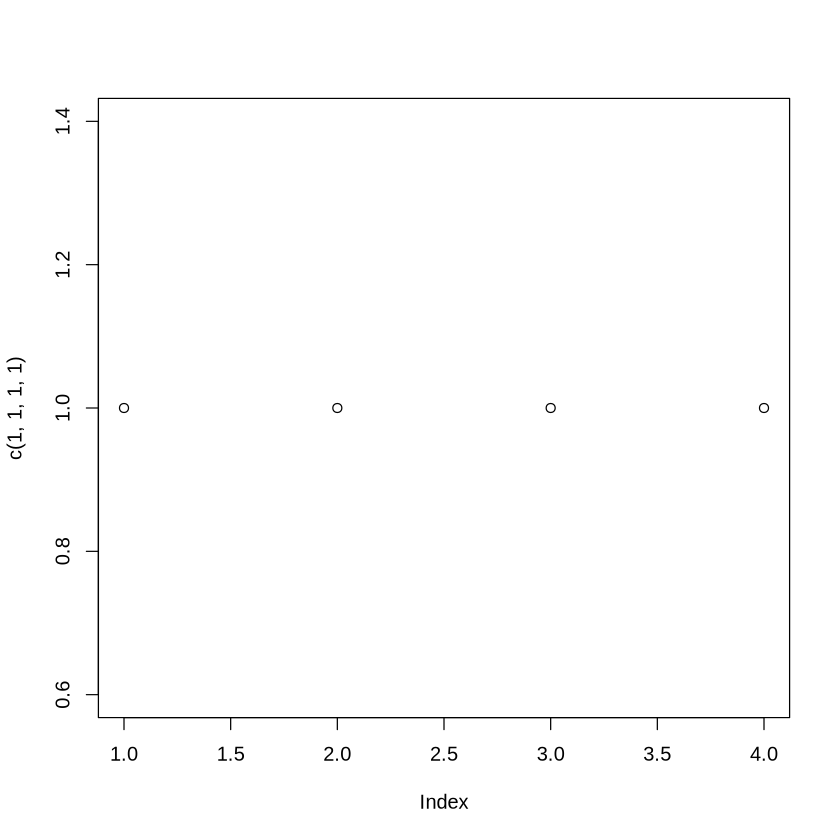

In [15]:
plot(c(1,1,1,1))

In [20]:
# ==============================================================================
# 3. MAP PLOTTING ----
# ==============================================================================
png <- 1
if (png) {
  png(filename = "outputs/Fig1.png", width = 1080, height = 720)
    
} else {
  pdf("outputs/Fig1.pdf")
}

Depth_cuts <- c(-8200 ,-7000 ,-6000 ,-5000, -4000, -3000, -1800, -1400, -1000,  -600,  -400 , -200  ,   0 ,   50  , 250   ,500)
Depth_cols <- c(
  "#D6EAF8", "#AED6F1", "#85C1E9", "#5DADE2", "#3498DB",
  "#5DADE2", "#85C1E9", "#A9CCE3", "#D4E6F1", "#EBF5FB",
  "#F4F6F7", "#F8F9F9", "#FDFEFE", "#F2F3F4", "#EAEDED"
)

# Plot bathymetry
plot(Bathy,breaks = Depth_cuts, col = Depth_cols, legend = FALSE, axes = FALSE, box = FALSE,mar=c(0,0,0,0))

# Save the plot ---
dev.off()


agg_record_1701121162 
                    2

## Data Exploration

In [26]:
head(Bathy,5)
dim(Bathy)

,global_topo_1min_topo_19_1
,<dbl>
1,-1539.120
2,-1538.341
3,-1539.416
4,-1540.569
5,-1540.435


[1]  9600 21600     1

ERROR: Error in attr(Bathy): either 2 or 3 arguments are required


In [27]:
summary(Bathy)

Warning message:
“[summary] used a sample”


 global_topo_1min_topo_19_1
 Min.   :-10775.9          
 1st Qu.: -4408.5          
 Median : -2818.9          
 Mean   : -2109.6          
 3rd Qu.:   136.3          
 Max.   :  6110.8          